In [1]:
# Useful imports and utilities

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os


from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
import matplotlib.ticker as mtick

In [2]:
import kagglehub
print("Kagglehub version:", kagglehub.__version__)

Kagglehub version: 0.4.1


In [3]:
salary_dataset_path = kagglehub.dataset_download("abhishek14398/salary-dataset-simple-linear-regression")

print("Path to dataset files:", salary_dataset_path)

Path to dataset files: /Users/gaurav/.cache/kagglehub/datasets/abhishek14398/salary-dataset-simple-linear-regression/versions/1


In [9]:
# Assuming the dataset is named "Salary_dataset.csv" inside the path
salary_dataset_path_to_file = os.path.join(salary_dataset_path, "Salary_dataset.csv")
salary_data_raw = pd.read_csv(salary_dataset_path_to_file)
salary_data_raw.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


## What are bins?
- Bins divide the data range into equal-width intervals.
- Each bin counts how many data points fall in that range.
- More bins = finer detail, but can be noisy.
- Fewer bins = smoother, but can hide detail.

How bins work:
If your salary data ranges from $20K to $100K and you use bins=10, you get 10 intervals (e.g., $20K–$28K, $28K–$36K, etc.).
The histogram shows how many data points fall into each interval.

- YMMV = "Your Mileage May Vary"

In [11]:
num_rows = len(salary_data_raw)
print(f"Number of rows: {num_rows}")


Number of rows: 30


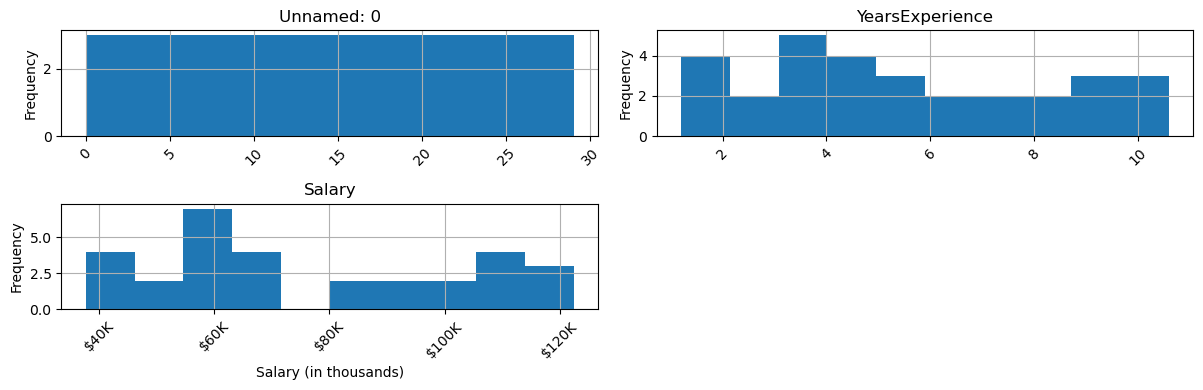

In [14]:
# Create histograms
axes = salary_data_raw.hist(bins=10, figsize=(12, 4))

# Format each axis
for i, ax in enumerate(axes.flatten()):
    # Get the column name from the title
    col_name = ax.get_title()
    
    # Format salary column specifically
    if 'Salary' in col_name or 'salary' in col_name.lower():
        ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))
        ax.set_xlabel('Salary (in thousands)')
    
    # Rotate all x-axis labels
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [15]:
# Your code here (not graded)
salary_data = salary_data_raw.drop(columns=['Unnamed: 0'])

feature_names = salary_data.columns.tolist()
print(f'Features: {feature_names}')

Features: ['YearsExperience', 'Salary']


In [16]:
# Your code here
X = salary_data.drop(columns=['Salary']).to_numpy()
y = salary_data['Salary'].to_numpy()

a4 = X.shape                 # replace 0,0 with an expression returning the shape of X
         

In [17]:
print(f"Type of X: {type(X)}")  # Should be <class 'numpy.ndarray'>
print(f"Shape of X: {X.shape}")  # Should be (30, 1)
print(f"Type of y: {type(y)}")  # Should also be numpy array

Type of X: <class 'numpy.ndarray'>
Shape of X: (30, 1)
Type of y: <class 'numpy.ndarray'>


## Matplotlib's behavior
plt.scatter() is more forgiving: it can handle 2D arrays and will extract the data automatically.
plt.plot() is stricter: it may interpret a 2D array differently, potentially plotting each column separately or causing unexpected behavior.
## Why flatten() helps
.flatten() converts a 2D array (30, 1) to a 1D array (30,), which both scatter() and plot() handle consistently.
## Consistency
If scatter() worked with X directly, you can try plot() with X too. However, using .flatten() (or .ravel()) ensures consistent behavior and avoids potential issues.